# EEG Lab — Notebook 3/5
## Filtering the EEG signal for ERP analysis

**Goals**
- Understand why we **filter** an EEG signal
- Apply a **band-pass filter** suited to **event-related potentials (ERPs)**: ~0.1–30 Hz
- Apply a **band-stop (notch) filter at 50 Hz** to remove mains noise (Europe)
- Compare the **raw** and **filtered** signal

> ⚠️ For ERPs like the P300, we filter **differently** than for rhythm analysis: the P300 is a **slow** wave, so we keep the low frequencies (lower low-pass, ~30 Hz) and cut very slow drifts (high-pass ~0.1 Hz).


### 1. Reload the data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch

data = np.load('oddball_data.npy')
channels = list(np.load('oddball_channels.npy'))
fs = 250

# We separate the EEG (first 8 rows) from the trigger channel (last)
eeg = data[:-1]
trig = data[-1]
print(f"EEG: {eeg.shape} | triggers: {trig.shape} | fs = {fs} Hz")

EEG: (8, 40000) | triggers: (40000,) | fs = 250 Hz


### 2. Why filter?
The raw EEG signal contains several unwanted sources:
- **very slow drifts** (< 0.1 Hz) caused by sweat, movement → we cut them with a **high-pass**.
- **high-frequency noise** (muscular, etc.) → we attenuate it with a **low-pass**.
- **50 Hz mains noise** (wall sockets in Europe) → we remove it with a **notch**.

The high-pass + low-pass combination forms a **band-pass**: we keep only the useful band.

### 3. The band-pass filter (0.1–30 Hz)
We use a **Butterworth** filter. The `filtfilt` function applies it **in both directions** so as not to shift the signal in time (crucial for ERPs!).

In [2]:
def band_pass(signal, flow, fhigh, fs, order=4):
    """Butterworth band-pass filter, applied without phase shift."""
    nyq = fs / 2                       # Nyquist frequency = fs/2 = 125 Hz
    b, a = butter(order, [flow/nyq, fhigh/nyq], btype='band')
    return filtfilt(b, a, signal, axis=-1)

# Band suited to ERPs: 0.1 Hz (removes drifts) to 30 Hz
F_LOW, F_HIGH = 0.1, 30.0
eeg_bp = band_pass(eeg, F_LOW, F_HIGH, fs)
print(f"Band-pass {F_LOW}-{F_HIGH} Hz applied.")

Band-pass 0.1-30.0 Hz applied.


### 4. The notch filter at 50 Hz
It removes the mains frequency. The `Q` parameter controls how narrow the notch is.

In [3]:
def notch_50(signal, fs, f0=50.0, Q=30.0):
    """Remove the mains component (50 Hz in Europe)."""
    b, a = iirnotch(f0, Q, fs)
    return filtfilt(b, a, signal, axis=-1)

eeg_filtered = notch_50(eeg_bp, fs, f0=50.0)
print("50 Hz notch applied. Signal fully filtered.")

50 Hz notch applied. Signal fully filtered.


### 5. Compare raw vs filtered
Let's look at the effect on the Pz electrode, over 5 seconds.

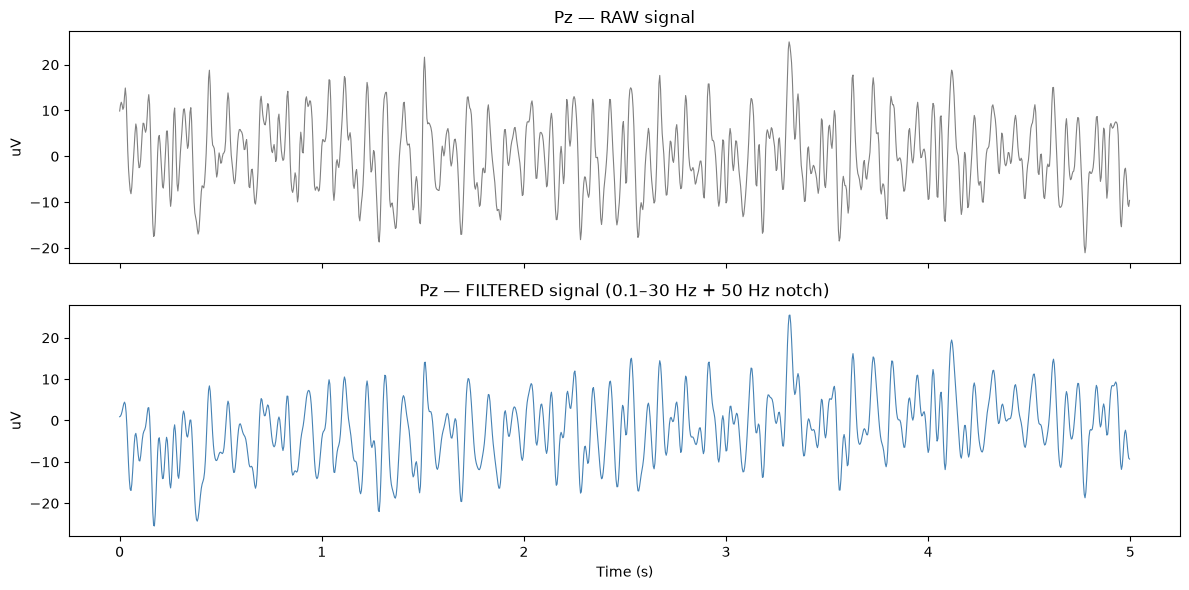

In [4]:
idx = channels.index('Pz')
duration = 5
n = int(duration*fs)
t = np.arange(n)/fs

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t, eeg[idx, :n], color='gray', lw=0.8)
ax[0].set_title('Pz — RAW signal')
ax[0].set_ylabel('uV')

ax[1].plot(t, eeg_filtered[idx, :n], color='steelblue', lw=0.8)
ax[1].set_title('Pz — FILTERED signal (0.1–30 Hz + 50 Hz notch)')
ax[1].set_ylabel('uV')
ax[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

### 6. Check in the frequency domain
A filter is "seen" better on the **spectrum** (the distribution of energy per frequency). We use a simple computation (Welch) here to check that the high frequencies and the 50 Hz have indeed been attenuated.

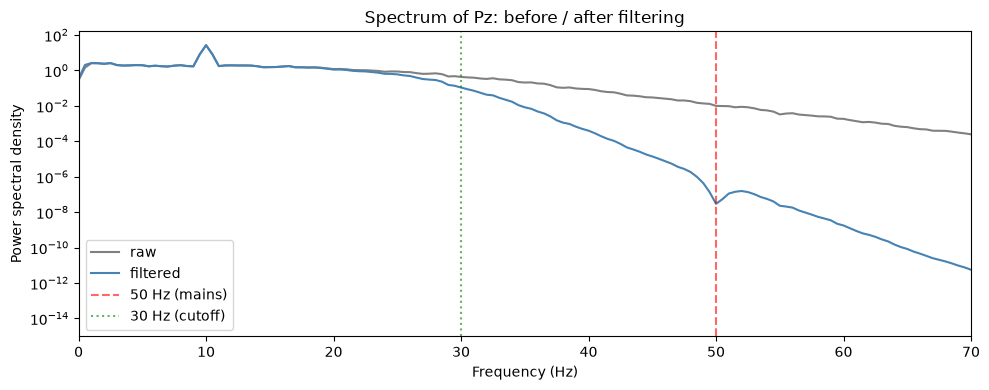

Beyond 30 Hz and around 50 Hz, the power of the filtered signal drops clearly.


In [5]:
from scipy.signal import welch

f_raw, p_raw = welch(eeg[idx], fs=fs, nperseg=fs*2)
f_filt, p_filt = welch(eeg_filtered[idx], fs=fs, nperseg=fs*2)

plt.figure(figsize=(10, 4))
plt.semilogy(f_raw, p_raw, color='gray', label='raw')
plt.semilogy(f_filt, p_filt, color='steelblue', label='filtered')
plt.axvline(50, color='red', ls='--', alpha=0.6, label='50 Hz (mains)')
plt.axvline(30, color='green', ls=':', alpha=0.6, label='30 Hz (cutoff)')
plt.xlim(0, 70)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power spectral density')
plt.title('Spectrum of Pz: before / after filtering')
plt.legend()
plt.tight_layout()
plt.show()

print("Beyond 30 Hz and around 50 Hz, the power of the filtered signal drops clearly.")

### 7. Save the filtered signal
We reassemble the filtered EEG + the trigger channel (which we do NOT filter — it must stay intact) and save.

In [6]:
data_filtered = np.vstack([eeg_filtered, trig[None, :]])
np.save('oddball_data_filtered.npy', data_filtered)
print(f"Saved: 'oddball_data_filtered.npy', shape {data_filtered.shape}")
print("The trigger channel was not filtered (it stays at 0/1/2).")

Saved: 'oddball_data_filtered.npy', shape (9, 40000)
The trigger channel was not filtered (it stays at 0/1/2).


---
### ✏️ Exercises
1. Redo the filtering with a low-pass cutoff at **15 Hz**. Is the Pz signal smoother?
2. What happens if we forget the notch? Plot the spectrum without applying it.
3. Why must we **never** filter the trigger channel?

### 🔑 Key takeaways
- For **ERPs**, we filter at **0.1–30 Hz**: we keep slow waves like the P300.
- The **50 Hz notch** removes electrical mains noise (Europe).
- `filtfilt` filters **without shifting the signal in time** — essential for measuring latencies.
- We **never** filter the trigger channel.
